<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/04_ARCH_models_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from joblib import Parallel, delayed

warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning
)

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/Quant Research"
)

PROCESSED_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

RESULTS_DIR = (
    PROJECT_DIR
    / "results"
    / "arch_family"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRAIN_PATH = (
    PROCESSED_DIR
    / "train_returns.parquet"
)

VALIDATION_PATH = (
    PROCESSED_DIR
    / "validation_returns.parquet"
)

TEST_PATH = (
    PROCESSED_DIR
    / "test_returns.parquet"
)

# IMPORTANT:
# Keep False until ALL DL / ARCH model choices are frozen.
RUN_FINAL_TEST = False

N_JOBS = -1

In [ ]:
train_returns = (
    pd.read_parquet(TRAIN_PATH)
    .sort_index()
)

validation_returns = (
    pd.read_parquet(VALIDATION_PATH)
    .sort_index()
)

test_returns = None

if RUN_FINAL_TEST:
    test_returns = (
        pd.read_parquet(TEST_PATH)
        .sort_index()
    )


# ---------------------------------------------------------
# Common numeric assets
# ---------------------------------------------------------

asset_cols = [
    c
    for c in train_returns.columns
    if (
        c in validation_returns.columns
        and pd.api.types.is_numeric_dtype(
            train_returns[c]
        )
        and pd.api.types.is_numeric_dtype(
            validation_returns[c]
        )
    )
]

if RUN_FINAL_TEST:
    asset_cols = [
        c
        for c in asset_cols
        if c in test_returns.columns
    ]


if not asset_cols:
    raise ValueError(
        "No common numeric asset columns found."
    )


# ---------------------------------------------------------
# Index checks
# ---------------------------------------------------------

if train_returns.index.has_duplicates:
    raise ValueError(
        "Training index contains duplicates."
    )

if validation_returns.index.has_duplicates:
    raise ValueError(
        "Validation index contains duplicates."
    )

if (
    train_returns.index.max()
    >= validation_returns.index.min()
):
    raise ValueError(
        "Train and validation periods overlap."
    )

if RUN_FINAL_TEST:

    if test_returns.index.has_duplicates:
        raise ValueError(
            "Test index contains duplicates."
        )

    if (
        validation_returns.index.max()
        >= test_returns.index.min()
    ):
        raise ValueError(
            "Validation and test periods overlap."
        )


print(
    "Train:",
    train_returns.shape,
    train_returns.index.min(),
    "to",
    train_returns.index.max()
)

print(
    "Validation:",
    validation_returns.shape,
    validation_returns.index.min(),
    "to",
    validation_returns.index.max()
)

if RUN_FINAL_TEST:
    print(
        "Test:",
        test_returns.shape,
        test_returns.index.min(),
        "to",
        test_returns.index.max()
    )

print("Assets:", asset_cols)

Train: (2540, 4) 2017-08-18 00:00:00+00:00 to 2024-07-31 00:00:00+00:00
Validation: (365, 4) 2024-08-01 00:00:00+00:00 to 2025-07-31 00:00:00+00:00
Assets: ['BTC', 'ETH', 'SOL', 'XRP']


In [ ]:
MODEL_SPECS = {
    "GARCH(1,1)": {"vol": "GARCH", "p": 1, "o": 0, "q": 1},
    "GJR-GARCH(1,1)": {"vol": "GARCH", "p": 1, "o": 1, "q": 1},
    "EGARCH(1,1)": {"vol": "EGARCH", "p": 1, "o": 1, "q": 1},
}

RETURN_SCALE = 100.0  # improves numerical conditioning for decimal returns
MIN_TRAIN_OBS = 100
EPSILON = 1e-12

def qlike(
    y_true,
    y_pred,
    epsilon=EPSILON
):

    y_true = np.maximum(
        np.asarray(
            y_true,
            dtype=float
        ),
        epsilon
    )

    y_pred = np.maximum(
        np.asarray(
            y_pred,
            dtype=float
        ),
        epsilon
    )

    ratio = y_true / y_pred

    return float(
        np.mean(
            ratio
            - np.log(ratio)
            - 1
        )
    )


def fit_and_forecast_one(
    asset,
    model_name,
    spec,
    evaluation_period="validation"
):
    """
    Fit parameters on TRAIN only.

    During validation/test:
    - parameters remain fixed
    - realized lagged returns update the
      conditional variance state
    - produce genuine one-step-ahead forecasts
    """

    train = (
        train_returns[asset]
        .dropna()
        .astype(float)
    )

    validation = (
        validation_returns[asset]
        .dropna()
        .astype(float)
    )

    if (
        len(train) < MIN_TRAIN_OBS
        or validation.empty
    ):
        return None

    train = train[
        np.isfinite(train)
    ]

    validation = validation[
        np.isfinite(validation)
    ]


    # -----------------------------------------------------
    # Decide which period is being evaluated
    # -----------------------------------------------------

    if evaluation_period == "validation":

        evaluation = validation

        history = pd.concat(
            [
                train,
                validation
            ]
        )

    elif evaluation_period == "test":

        if test_returns is None:
            raise RuntimeError(
                "Test data has not been enabled."
            )

        test = (
            test_returns[asset]
            .dropna()
            .astype(float)
        )

        test = test[
            np.isfinite(test)
        ]

        evaluation = test

        # CRITICAL:
        # validation history MUST sit between
        # training and test.
        history = pd.concat(
            [
                train,
                validation,
                test
            ]
        )

    else:
        raise ValueError(
            "evaluation_period must be "
            "'validation' or 'test'."
        )


    # -----------------------------------------------------
    # Scaling
    # -----------------------------------------------------

    y_train = (
        train * RETURN_SCALE
    )

    y_history = (
        history * RETURN_SCALE
    )


    # -----------------------------------------------------
    # Estimate parameters using TRAIN ONLY
    # -----------------------------------------------------

    train_model = arch_model(
        y_train,
        mean="Constant",
        dist="t",
        rescale=False,
        **spec
    )

    fit = train_model.fit(
        disp="off",
        show_warning=False,
        update_freq=0
    )


    # -----------------------------------------------------
    # Fixed parameters + recursive state updating
    # -----------------------------------------------------

    full_model = arch_model(
        y_history,
        mean="Constant",
        dist="t",
        rescale=False,
        **spec
    )

    fixed = full_model.fix(
        fit.params
    )


    forecasts = fixed.forecast(
        horizon=1,
        start=len(train) - 1,
        align="target",
        reindex=True
    )


    variance_scaled = (
        forecasts
        .variance["h.1"]
        .reindex(
            evaluation.index
        )
    )


    # Convert %-return variance
    # back to decimal-return variance
    variance = (
        variance_scaled
        / (RETURN_SCALE ** 2)
    )

    variance = variance.clip(
        lower=EPSILON
    )


    # Same target as DL:
    # daily squared log return
    realized_variance = (
        evaluation ** 2
    )


    valid = (
        variance.notna()
        & realized_variance.notna()
    )

    variance = variance[valid]

    realized_variance = (
        realized_variance[valid]
    )


    if variance.empty:
        return None


    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    errors = (
        variance
        - realized_variance
    )

    rmse = float(
        np.sqrt(
            np.mean(
                errors ** 2
            )
        )
    )

    mae = float(
        np.mean(
            np.abs(errors)
        )
    )

    qlike_value = qlike(
        realized_variance,
        variance
    )


    forecast_table = pd.DataFrame({
        "asset": asset,
        "model": model_name,
        "evaluation_period":
            evaluation_period,

        "return":
            evaluation.reindex(
                variance.index
            ),

        "realized_variance":
            realized_variance,

        "forecast_variance":
            variance,

        "forecast_volatility":
            np.sqrt(variance),
    })


    metric_row = {
        "asset": asset,
        "model": model_name,

        "evaluation_period":
            evaluation_period,

        "n_train": len(train),

        "n_observations":
            len(variance),

        "converged":
            fit.convergence_flag == 0,

        "loglikelihood":
            float(
                fit.loglikelihood
            ),

        "rmse": rmse,
        "mae": mae,
        "qlike": qlike_value,
    }


    return (
        forecast_table,
        metric_row
    )


In [ ]:
validation_jobs = [
    (
        asset,
        model_name,
        spec
    )
    for asset in asset_cols
    for model_name, spec
    in MODEL_SPECS.items()
]


start = perf_counter()

validation_results = Parallel(
    n_jobs=N_JOBS,
    prefer="processes"
)(
    delayed(
        fit_and_forecast_one
    )(
        asset,
        model_name,
        spec,
        "validation"
    )
    for (
        asset,
        model_name,
        spec
    ) in validation_jobs
)


validation_results = [
    r
    for r in validation_results
    if r is not None
]


elapsed = (
    perf_counter()
    - start
)


if not validation_results:
    raise RuntimeError(
        "No ARCH models produced "
        "valid validation forecasts."
    )


validation_forecasts = pd.concat(
    [
        r[0]
        for r
        in validation_results
    ]
).sort_index()


validation_metrics = (
    pd.DataFrame(
        [
            r[1]
            for r
            in validation_results
        ]
    )
    .sort_values(
        [
            "asset",
            "qlike"
        ]
    )
    .reset_index(
        drop=True
    )
)


validation_forecasts.to_parquet(
    RESULTS_DIR
    / "arch_validation_forecasts.parquet"
)

validation_metrics.to_csv(
    RESULTS_DIR
    / "arch_validation_metrics.csv",
    index=False
)


print(
    f"Completed "
    f"{len(validation_results)} "
    f"validation fits in "
    f"{elapsed:.2f}s."
)

display(validation_metrics)

Completed 12 validation fits in 2.79s.


,asset,model,evaluation_period,n_train,n_observations,converged,loglikelihood,rmse,mae,qlike
0,BTC,"GARCH(1,1)",validation,2540,365,True,-6516.449481,0.001353,0.000820,1.865873
1,BTC,"GJR-GARCH(1,1)",validation,2540,365,True,-6515.915099,0.001356,0.000818,1.871827
2,BTC,"EGARCH(1,1)",validation,2540,365,True,-6502.973937,0.001434,0.000973,1.943311
3,ETH,"GARCH(1,1)",validation,2540,365,True,-7177.067714,0.003583,0.002023,1.855979
4,ETH,"GJR-GARCH(1,1)",validation,2540,365,True,-7176.912914,0.003583,0.002013,1.856590
5,ETH,"EGARCH(1,1)",validation,2540,365,True,-7163.799570,0.003580,0.002044,1.878446
6,SOL,"GARCH(1,1)",validation,1450,365,True,-4615.793869,0.004815,0.002616,1.650260
7,SOL,"GJR-GARCH(1,1)",validation,1450,365,True,-4615.768423,0.004811,0.002614,1.650744
8,SOL,"EGARCH(1,1)",validation,1450,365,True,-4618.561843,0.004786,0.002587,1.657325
9,XRP,"EGARCH(1,1)",validation,2280,365,True,-6355.037747,0.007040,0.003402,1.914143


In [ ]:
best_arch_by_asset = (
    validation_metrics
    .sort_values(
        [
            "asset",
            "qlike",
            "mae",
            "rmse"
        ]
    )
    .groupby(
        "asset",
        as_index=False
    )
    .first()
)


print(
    "Best ARCH-family model "
    "by validation QLIKE:"
)

display(
    best_arch_by_asset[
        [
            "asset",
            "model",
            "qlike",
            "mae",
            "rmse",
            "converged"
        ]
    ]
)


best_arch_by_asset.to_csv(
    RESULTS_DIR
    / "best_arch_model_by_asset.csv",
    index=False
)

Best ARCH-family model by validation QLIKE:


,asset,model,qlike,mae,rmse,converged
0,BTC,"GARCH(1,1)",1.865873,0.000820,0.001353,True
1,ETH,"GARCH(1,1)",1.855979,0.002023,0.003583,True
2,SOL,"GARCH(1,1)",1.650260,0.002616,0.004815,True
3,XRP,"EGARCH(1,1)",1.914143,0.003402,0.007040,True


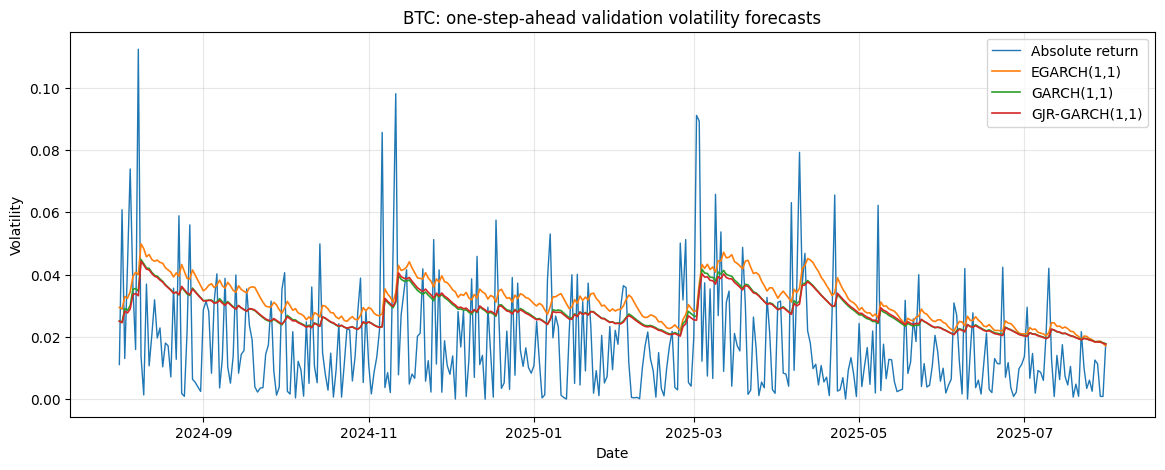

In [ ]:
asset_to_plot = asset_cols[0]

plot_data = (
    validation_forecasts.loc[
        validation_forecasts[
            "asset"
        ].eq(asset_to_plot)
    ]
)


actual_validation = (
    validation_returns[
        asset_to_plot
    ]
    .abs()
)


plt.figure(
    figsize=(14, 5)
)

plt.plot(
    actual_validation.index,
    actual_validation,
    label="Absolute return",
    linewidth=1
)


for (
    model_name,
    group
) in plot_data.groupby(
    "model"
):

    plt.plot(
        group.index,
        group[
            "forecast_volatility"
        ],
        label=model_name,
        linewidth=1.2
    )


plt.title(
    f"{asset_to_plot}: "
    "one-step-ahead validation "
    "volatility forecasts"
)

plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### To Check the Test Values

In [ ]:
selected_specs = {
    row["asset"]: row["model"]
    for _, row
    in best_arch_by_asset.iterrows()
}


test_jobs = [
    (
        asset,
        selected_specs[asset],
        MODEL_SPECS[
            selected_specs[asset]
        ]
    )
    for asset
    in asset_cols
]


test_results = Parallel(
    n_jobs=N_JOBS,
    prefer="processes"
)(
    delayed(
        fit_and_forecast_one
    )(
        asset,
        model_name,
        spec,
        "test"
    )
    for (
        asset,
        model_name,
        spec
    ) in test_jobs
)


test_results = [
    r
    for r
    in test_results
    if r is not None
]


test_forecasts = pd.concat(
    [
        r[0]
        for r
        in test_results
    ]
).sort_index()


test_metrics = (
    pd.DataFrame(
        [
            r[1]
            for r
            in test_results
        ]
    )
    .sort_values("asset")
    .reset_index(drop=True)
)


test_forecasts.to_parquet(
    RESULTS_DIR
    / "arch_final_test_forecasts.parquet"
)

test_metrics.to_csv(
    RESULTS_DIR
    / "arch_final_test_metrics.csv",
    index=False
)


display(test_metrics)